# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

### Group #62. My Project title: The Hidden Cost of Overproducing STEM Graduate

For this week, I'm going to use this dataset below to track STEM enrollment trends at institutional and state levels

- **Current Term Enrollment Estimates**

  (National Student Clearinghouse Research Center)

    https://nscresearchcenter.org/current-term-enrollment-estimates/
    
#### Keys to Analyze:

I wanted to learn more about:

- Enrollment by field: STEM vs. non-STEM enrollment rates over time 

- Student demographics: Age groups, race/ethnicity, gender distribution in STEM programs

However, both of these questions can't be answered with this week's dataset. I need to go back to Week 2 Dataset. I'll defer those analysis on the next assignment.

For this week, I'll analyze these:

- Enrollment by field: STEM vs. non-STEM enrollment rates over time 

- Institutional characteristics: Public vs. private 

- Credential types: Certificate, associate, bachelor's enrollment patterns 

#### Questions to answer:

- How has STEM enrollment changed over the past 5-10 years at different institution types?

- Are community colleges seeing different STEM enrollment trends than 4-year institutions?

- Which regions have the highest/lowest coverage rates?

- Do private for-profit institutions have different coverage patterns than public?

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

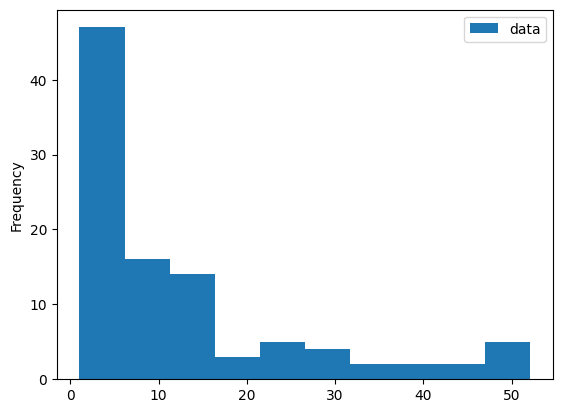

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

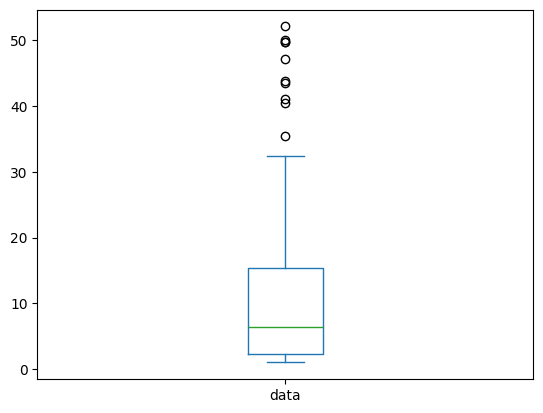

In [3]:
df.plot.box()

### Answer for #2

#### Observations:

- The histogram graph:
  - Individual expensive drugs get lost somewhere, making it hard to see exactly how high they go.
  - No x-axis label, making it hard to understand what they're represented
  - No chart title

- The box plot:
  - I can't tell the data is skewed or see the density of lower/higher cost drugs.
  - No y-axix label, making it hard to understand what they're represented
  - No chart title

**What can be improved?**

- Add chart titles for both

- Clearly label both charts x-axis and y-axis

- For the boxplot, add an annotation for the 75th percentile line

- Show 25%, 75% quantize, and median for better visual effect

- Highline any outliers

D:\Users\Dustin\AppData\Local\Temp\ipykernel_22208\827027224.py:43: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax.text(1.1, float(outliers.max()) + 0.5, f' {len(outliers)} expensive drugs',


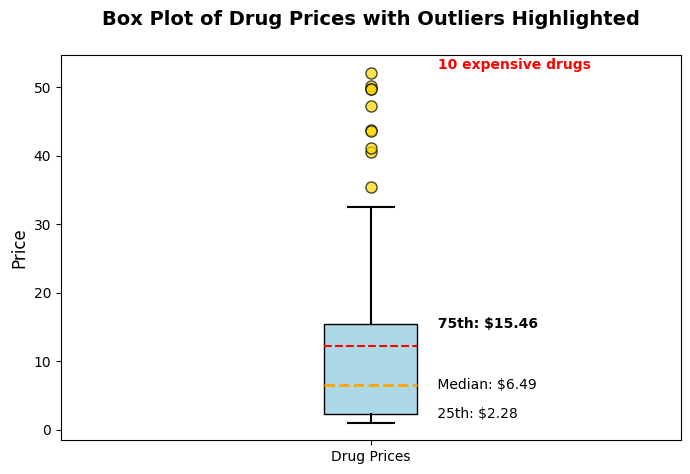

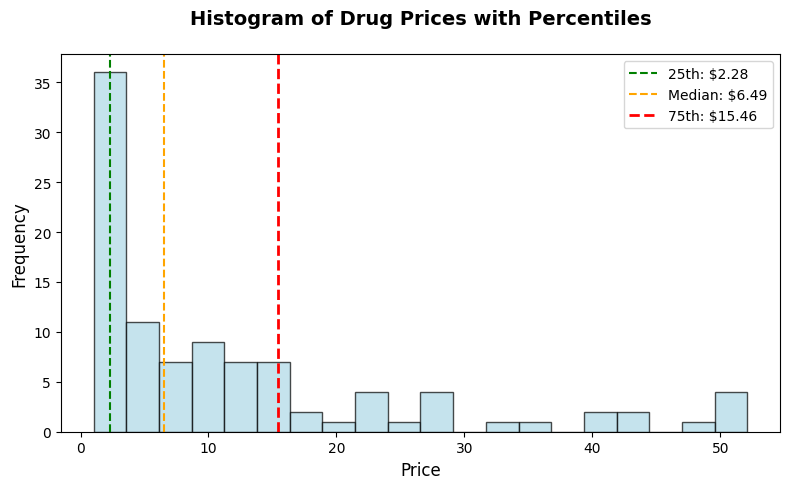

In [4]:
# Generate data for drug prices
np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size=num_data) * 4)
df = pd.DataFrame(data.T, columns=["data"])

# Calculate statistics for annotations
q25 = df["data"].quantile(0.25)
q50 = df["data"].median()
q75 = df["data"].quantile(0.75)

# Identify outliers (drugs priced above the upper whisker)
# Reference: Outliers are typically defined as data points that are above Q3 + 1.5*IQR or below Q1 - 1.5*IQR
# https://chartio.com/resources/tutorials/what-is-a-box-plot/#:~:text=Mathematician%20John%20Tukey%20first%20introduced,of%20any%20given%20data%20set.

outliers = df[df["data"] > q75 + 1.5*(q75-q25)]

# Create new box plot
fig, ax = plt.subplots(figsize=(8, 5))

# Customize new box plot
box = ax.boxplot(df["data"], 
                 patch_artist=True,
                 showmeans=True,
                 meanline=True,
                 medianprops={'color': 'orange', 'linewidth': 2, 'linestyle': '--'},
                 meanprops={'color': 'red', 'linewidth': 1.5, 'linestyle': '--'},
                 whiskerprops={'color': 'black', 'linewidth': 1.5},
                 capprops={'color': 'black', 'linewidth': 1.5},
                 flierprops={'marker': 'o', 'markerfacecolor': 'gold', 
                            'markersize': 8, 'alpha': 0.7})

# Set the box color
box['boxes'][0].set_facecolor('lightblue')

# Add labels for percentiles
ax.text(1.1, q25, f' 25th: ${q25:.2f}', va='center', fontsize=10)
ax.text(1.1, q50, f' Median: ${q50:.2f}', va='center', fontsize=10)
ax.text(1.1, q75, f' 75th: ${q75:.2f}', va='center', fontsize=10, fontweight='bold')

# Highlight number of expensive drugs - those above the upper whisker
if len(outliers) > 0:
    ax.text(1.1, float(outliers.max()) + 0.5, f' {len(outliers)} expensive drugs', 
            fontsize=10, color='red', fontweight='bold')    

# Add labels and title
ax.set_ylabel('Price', fontsize=12)
ax.set_xticklabels(['Drug Prices'])
ax.set_title('Box Plot of Drug Prices with Outliers Highlighted\n', 
             fontsize=14, fontweight='bold')

# For the histogram, we can also add vertical lines to indicate the 25th, 50th, and 75th percentiles 
# for better visualization.

fig2, ax2 = plt.subplots(figsize=(8, 5))

ax2.hist(df['data'], bins=20, color='lightblue', edgecolor='black', alpha=0.7)
ax2.axvline(q25, color='green', linestyle='--', linewidth=1.5, label=f'25th: ${q25:.2f}')
ax2.axvline(q50, color='orange', linestyle='--', linewidth=1.5, label=f'Median: ${q50:.2f}')
ax2.axvline(q75, color='red', linestyle='--', linewidth=2, label=f'75th: ${q75:.2f}')

ax2.set_xlabel('Price', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Histogram of Drug Prices with Percentiles\n', fontsize=14, fontweight='bold')
ax2.legend()
plt.tight_layout()

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

### My Week 4 Analysis

For this week, I'm going to use this dataset below to track STEM enrollment trends at institutional and state levels

- **Current Term Enrollment Estimates**

  (National Student Clearinghouse Research Center)

    https://nscresearchcenter.org/current-term-enrollment-estimates/

#### File Structure Summary:
- Coverage Files (Percentages): These show the percentage of institutions covered by NSC data

  - 03-21_COVERAGE.csv - Coverage % by institution type and region for 2003-2021

- Multi-State Files (Percentages):

  - 03-21_MULTI_STATE.csv - Multi-state institution coverage % for 2003-2021

- NSC Coverage Files (Actual Counts):

  - 03-21_NSC_COVERAGE.csv - Enrollment counts (Active vs IPEDS Universe) for 2003-2021

- Key Variables Across All Files:

  - State or Region (United States, regions, individual states)

  - Institution Sector (Overall, 4-year, 2-year, Public, Private...)

  - Year columns (Fall_2003 through Fall_2021)

#### Question to answer:

- Question 1: How has NSC coverage changed over time?

- Question 2: Are community colleges better covered than 4-year institutions?

- Question 3: Which regions have the highest/lowest coverage rates?

- Question 4: Do private for-profit institutions have different coverage patterns? 

In [5]:
# Import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [18]:
# Preprocess the data

# Load the coverage file
df = pd.read_csv('03-21_COVERAGE.csv')

# Clean percentage values (handle dots and % signs)
def clean_pct(val):
    if pd.isna(val) or str(val).strip() == '' or str(val).strip() == '.':
        return np.nan
    try:
        return float(str(val).replace('%', '').strip())
    except:
        return np.nan

# Get year columns, clean them, and convert to numeric
year_cols = [col for col in df.columns if col.startswith('Fall_')]
for col in year_cols:
    df[col] = df[col].apply(clean_pct)

# Extract years as numbers for plotting
years = [int(col.replace('Fall_', '')) for col in year_cols]

Overall coverage increased from 86.5% in 2003 to 97.4% in 2021
Total gain: +10.9 percentage points


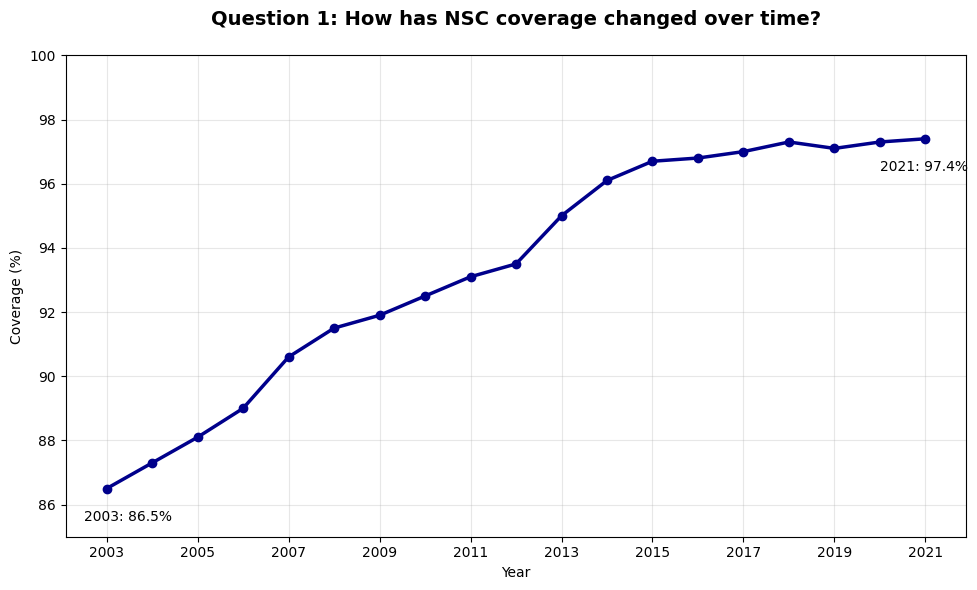

In [21]:
# Filter for nation wide data (United States)
us_data = df[df['State or Region'] == 'United States']

# Overall coverage trend
overall = us_data[us_data['Institution Sector'] == 'Overall'].iloc[0]
overall_values = [overall[col] for col in year_cols]

plt.figure(figsize=(10, 6))
plt.plot(years, overall_values, 'o-', linewidth=2.5, color='darkblue', markersize=6)
plt.xlabel('Year')
plt.ylabel('Coverage (%)')
plt.title('Question 1: How has NSC coverage changed over time?\n', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(85, 100)

# Show labels every 2 years
plt.xticks(ticks=years[::2], labels=years[::2])

# Add annotations
plt.annotate(f'2003: {overall_values[0]:.1f}%', xy=(years[0], overall_values[0]), 
             xytext=(years[0]-.5, overall_values[0]-1))
plt.annotate(f'2021: {overall_values[-1]:.1f}%', xy=(years[-1], overall_values[-1]), 
             xytext=(years[-1]-1, overall_values[-1]-1))

plt.tight_layout()

print(f"Overall coverage increased from {overall_values[0]:.1f}% in 2003 to {overall_values[-1]:.1f}% in 2021")
print(f"Total gain: {overall_values[-1] - overall_values[0]:+.1f} percentage points")

2003 gap (4-year - 2-year): +3.6 percentage points
2021 gap (4-year - 2-year): +1.7 percentage points


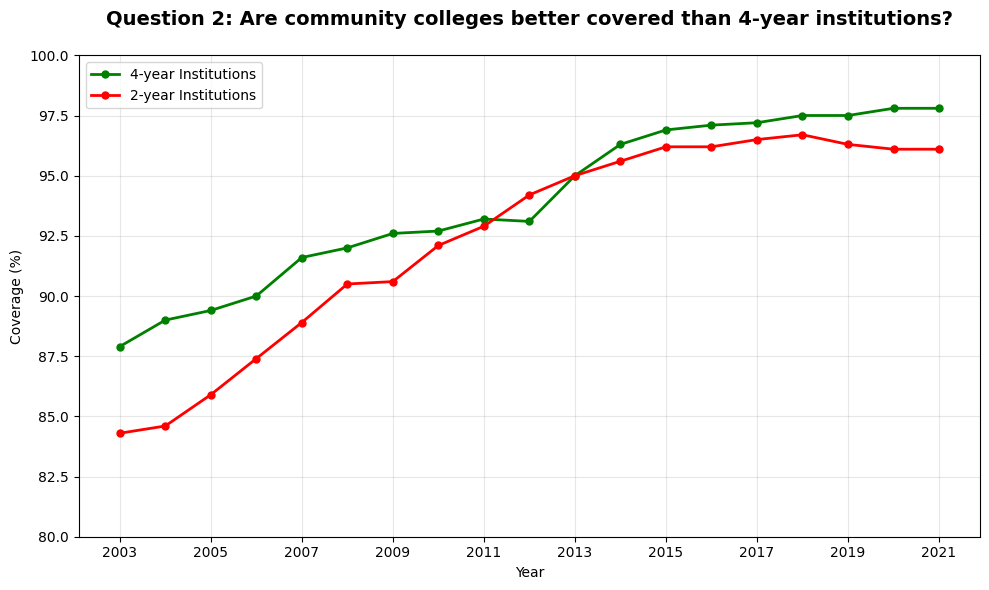

In [8]:
# Get data for comparison
four_year = us_data[us_data['Institution Sector'] == 'All 4-year Institutions'].iloc[0]
two_year = us_data[us_data['Institution Sector'] == 'All 2-year Institutions'].iloc[0]

four_values = [four_year[col] for col in year_cols]
two_values = [two_year[col] for col in year_cols]

plt.figure(figsize=(10, 6))
plt.plot(years, four_values, 'o-', linewidth=2, label='4-year Institutions', color='green', markersize=5)
plt.plot(years, two_values, 'o-', linewidth=2, label='2-year Institutions', color='red', markersize=5)
plt.xlabel('Year')
plt.ylabel('Coverage (%)')
plt.title('Question 2: Are community colleges better covered than 4-year institutions?\n', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(80, 100)

# Show labels every 2 years
plt.xticks(ticks=years[::2], labels=years[::2])
plt.tight_layout()

# Calculate the gap
gap_2003 = four_values[0] - two_values[0]
gap_2021 = four_values[-1] - two_values[-1]

print(f"2003 gap (4-year - 2-year): {gap_2003:+.1f} percentage points")
print(f"2021 gap (4-year - 2-year): {gap_2021:+.1f} percentage points")


REGIONAL COVERAGE IN 2021:
----------------------------------------
Northeast: 97.6%
Midwest: 98.4%
South: 97.4%
West: 96.8%

Highest: Midwest (98.4%)
Lowest: West (96.8%)
Range: 1.6 percentage points


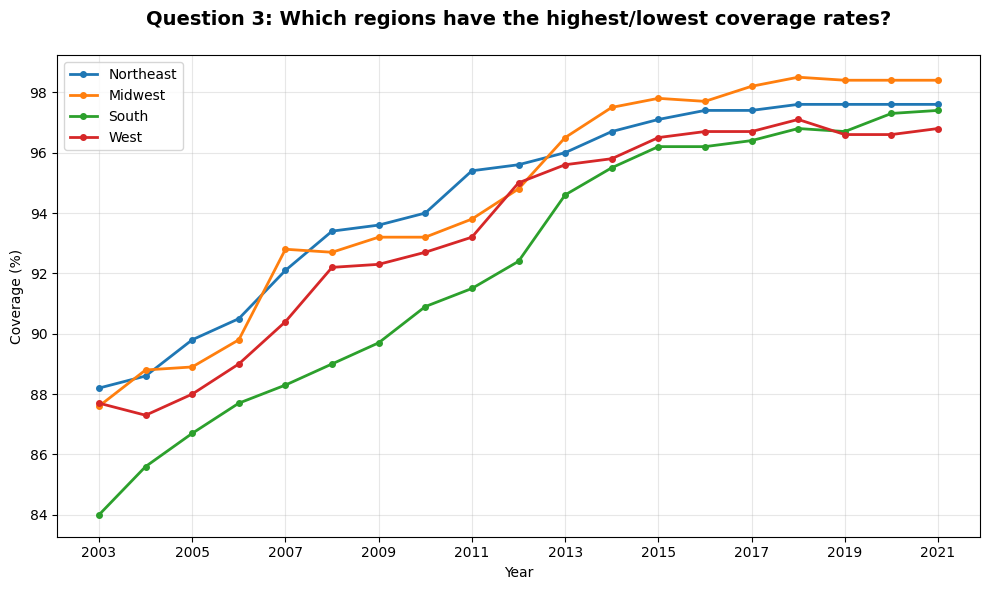

In [9]:
regions = ['Northeast', 'Midwest', 'South', 'West']

plt.figure(figsize=(10, 6))

for region in regions:
    region_data = df[(df['State or Region'] == region) & 
                     (df['Institution Sector'] == 'Overall')]
    if len(region_data) > 0:
        values = [region_data.iloc[0][col] for col in year_cols]
        plt.plot(years, values, 'o-', linewidth=2, markersize=4, label=region)

plt.xlabel('Year')
plt.ylabel('Coverage (%)')
plt.title('Question 3: Which regions have the highest/lowest coverage rates?\n', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Show labels every 2 years
plt.xticks(ticks=years[::2], labels=years[::2])
plt.tight_layout()

# Latest year comparison
latest_year = years[-1]
print(f"\nREGIONAL COVERAGE IN {latest_year}:")
print("-" * 40)
region_vals = {}
for region in regions:
    region_data = df[(df['State or Region'] == region) & 
                     (df['Institution Sector'] == 'Overall')]
    if len(region_data) > 0:
        val = region_data.iloc[0][year_cols[-1]]
        region_vals[region] = val
        print(f"{region}: {val:.1f}%")

# Find highest and lowest
highest = max(region_vals, key=region_vals.get)
lowest = min(region_vals, key=region_vals.get)
print(f"\nHighest: {highest} ({region_vals[highest]:.1f}%)")
print(f"Lowest: {lowest} ({region_vals[lowest]:.1f}%)")
print(f"Range: {region_vals[highest] - region_vals[lowest]:.1f} percentage points")


PRIVATE FOR-PROFIT COVERAGE:
2003: 45.2%
2021: 71.4%
Change: +26.2 percentage points

PUBLIC INSTITUTIONS COVERAGE:
2003: 89.9%
2021: 99.6%
Change: +9.7 percentage points

Public - For-profit gap:
2003: +44.7 points
2021: +28.2 points


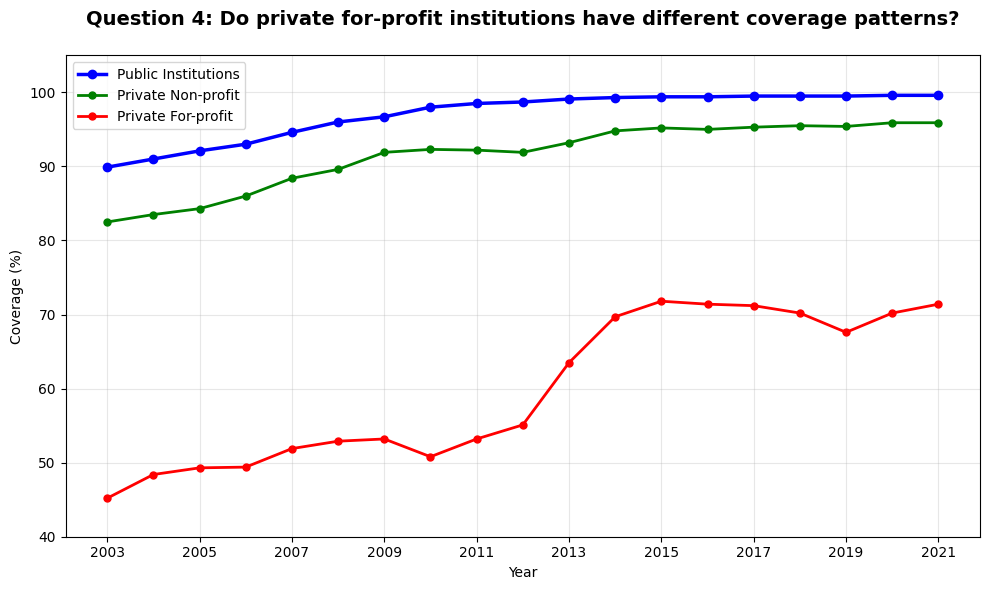

In [10]:
# Compare public vs private
public = us_data[us_data['Institution Sector'] == 'All Public Institutions'].iloc[0]
private_nonprofit = us_data[us_data['Institution Sector'] == 'All Private, not-for-profit Institutions'].iloc[0]
private_forprofit = us_data[us_data['Institution Sector'] == 'All Private, for-profit Institutions'].iloc[0]

public_values = [public[col] for col in year_cols]
nonprofit_values = [private_nonprofit[col] for col in year_cols]
forprofit_values = [private_forprofit[col] for col in year_cols]

plt.figure(figsize=(10, 6))
plt.plot(years, public_values, 'o-', linewidth=2.5, label='Public Institutions', color='blue', markersize=6)
plt.plot(years, nonprofit_values, 'o-', linewidth=2, label='Private Non-profit', color='green', markersize=5)
plt.plot(years, forprofit_values, 'o-', linewidth=2, label='Private For-profit', color='red', markersize=5)
plt.xlabel('Year')
plt.ylabel('Coverage (%)')
plt.title('Question 4: Do private for-profit institutions have different coverage patterns?\n', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(40, 105)

# Show labels every 2 years
plt.xticks(ticks=years[::2], labels=years[::2])
plt.tight_layout()

print(f"\nPRIVATE FOR-PROFIT COVERAGE:")
print(f"2003: {forprofit_values[0]:.1f}%")
print(f"2021: {forprofit_values[-1]:.1f}%")
print(f"Change: {forprofit_values[-1] - forprofit_values[0]:+.1f} percentage points")

print(f"\nPUBLIC INSTITUTIONS COVERAGE:")
print(f"2003: {public_values[0]:.1f}%")
print(f"2021: {public_values[-1]:.1f}%")
print(f"Change: {public_values[-1] - public_values[0]:+.1f} percentage points")

# Gap between public and for-profit
gap_2003 = public_values[0] - forprofit_values[0]
gap_2021 = public_values[-1] - forprofit_values[-1]
print(f"\nPublic - For-profit gap:")
print(f"2003: {gap_2003:+.1f} points")
print(f"2021: {gap_2021:+.1f} points")

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

#### Load data from HW2

Since I need to the dataset from HW2, I'll copy the code from HW2 here for this week analysis

In [11]:
# Code copy from HW2 here for this week analysis

# Load epcg23 and Dpcg23 for column lookup
df = pd.read_csv('epcg23.zip')
dict_df = pd.read_csv('Dpcg23.csv')

# Function to lookup column information
def lookup_col(col_name):

    result = dict_df[dict_df['SAS_NAME'] == col_name.upper()]
    if len(result) > 0:
        row = result.iloc[0]
        print(f"\nColumn Name: {col_name}")
        print(f"Description: {row['DESCRIPTION']}")
        print(f"Domain: {row['DOMAIN']}")
        print(f"Question: {row['QUESTION']}")
        
    else:
        print(f"Column '{col_name}' not found")

# Identify the invalid max values
invalid_mask = df['EARN'] >= 9999990  # Values close to 10 million

# Remove them
df_clean = df[~invalid_mask].copy()

# Clean high outliers by capping at the 99th percentile
earnings_99th = df_clean['EARN'].quantile(0.99)

# remove values above the 99th percentile
df_clean_99 = df_clean[df_clean['EARN'] <= earnings_99th].copy()

# Load the major codes file to determine STEM vs non-STEM majors
majors_df = pd.read_csv('N2BAMED.csv')

D:\Users\Dustin\AppData\Local\Temp\ipykernel_22208\2209463886.py:4: DtypeWarning: Columns (231,232,233,234,235,236,237,238,239) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('epcg23.zip')


In [12]:
# Look up a few of the column names for references

# Education variables
lookup_col('DGRYR')       # Year of highest degree
lookup_col('BAYR')        # Year of bachelor's degree

# Employment variables
lookup_col('SALARY')      # Annual salary
lookup_col('WKSLYR')      # Weeks worked

# Cost variables
lookup_col('UGLOANR')     # Undergraduate loans
lookup_col('GRLOANR')     # Graduate loans


Column Name: DGRYR
Description: Year of award of highest degree
Domain: All respondents
Question: In what year was your highest degree awarded?

Column Name: BAYR
Description: Year of award of first bachelor's degree
Domain: All respondents
Question: In what year was your first BA degree awarded?

Column Name: SALARY
Description: Salary (annualized)
Domain: Working during the week of February 1, 2023
Question: As of the week of February 1, 2023, what was your basic annual salary on your principal job, before deductions?

Column Name: WKSLYR
Description: Number of weeks worked per year if less than 52 weeks
Domain: Working during the week of February 1, 2023
Question: Was this salary based on a 52-week year, or less than that? (Responded "Less than 52 weeks" and entered number of weeks per year.)

Column Name: UGLOANR
Description: Amount borrowed to finance UNDERGRADUATE degree(s)
Domain: All respondents
Question: Completed Undergraduate Degrees- Total amount borrowed

Column Name: GRL

In [13]:
# Categorical variables using the major codes from N2BAMED.csv

# 1. Create STEM classification in majors_df
# These are common keywords that often indicate a STEM field. 
# Defined by the National Science Foundation and other organizations.

stem_keywords = [
    'computer', 'information', 'engineering', 'mathematics', 'statistics',
    'physics', 'chemistry', 'biology', 'biochemistry', 'neuroscience',
    'astronomy', 'geology', 'environmental science', 'materials science',
    'applied mathematics', 'operations research', 'data science', 'science',
    'technology', 'mechanical', 'electrical', 'civil', 'chemical', 'aerospace'
]

def is_stem_field(desc):
    # Determine if a field description is STEM based on keywords
    if pd.isna(desc):
        return 0
    desc_lower = str(desc).lower()
    for keyword in stem_keywords:
        if keyword in desc_lower:
            return 1
    return 0

majors_df['is_stem'] = majors_df['Description'].apply(is_stem_field)

# Check STEM classification
print("STEM Classification Sample:")
print(majors_df.head(10))
print(f"\nSTEM fields: {majors_df['is_stem'].sum()} out of {len(majors_df)}")

# 2. Create mapping dictionaries
major_to_stem = dict(zip(majors_df['Value'], majors_df['is_stem']))
major_to_desc = dict(zip(majors_df['Value'], majors_df['Description']))

# 3. Apply to main dataset
df_final = df_clean_99.copy()

# Map using N2BAMED column
df_final['is_stem_major'] = df_final['N2BAMED'].map(major_to_stem)
df_final['major_desc'] = df_final['N2BAMED'].map(major_to_desc)

# 4. Check merge results
mapped = df_final['is_stem_major'].notna().sum()
total = len(df_final)
print(f"\n{'='*50}")
print(f"MERGE RESULTS")
print(f"{'='*50}")

if mapped > 0:
    stem_count = df_final['is_stem_major'].sum()
    print(f"STEM majors: {stem_count:,} ({stem_count/mapped*100:.1f}% of mapped)")
    print(f"Non-STEM majors: {mapped - stem_count:,}")

# 5. Create analysis variables
df_final['total_debt'] = df_final['UGLOANR'] + df_final['GRLOANR'].fillna(0)

# Filter to recent graduates (last 10 years)
recent_year = df_final['BAYR'].max() - 10
df_recent = df_final[df_final['BAYR'] >= recent_year].copy()
print(f"\nRecent graduates (since {recent_year}): {len(df_recent):,}")

# 6. Create cohorts
df_recent['cohort'] = pd.cut(
    df_recent['BAYR'],
    bins=[2013, 2015, 2017, 2019, 2021, 2023],
    labels=['2013-15', '2015-17', '2017-19', '2019-21', '2021-23']
)

STEM Classification Sample:
    Value                                  Description  is_stem
0  116710  Computer and information sciences general          1
1  116730                           Computer science          1
2  116740                  Computer systems analysis          1
3  116760                Information science studies          1
4  116770    Other computer and information sciences          1
5  128410                        Applied mathematics          1
6  128420                        Mathematics general          1
7  128430                        Operations research          1
8  128440                                 Statistics          1
9  128450                          Other mathematics          1

STEM fields: 67 out of 139

MERGE RESULTS
STEM majors: 44,425 (53.5% of mapped)
Non-STEM majors: 38,552

Recent graduates (since 9988): 5,692


In [14]:
# The last print statement indicated some invalid years
# Found 5692 invalid years of 9998.
# I'll clean those up by removing records with DGRYR >= 9998, which indicates missing/invalid data for highest degree year.

# Filter out invalid years
valid_years = df_final[df_final['BAYR'] < 2026]

# Get recent graduates (last 10 years from the MAX valid year)
max_valid_year = valid_years['BAYR'].max()
recent_year = max_valid_year - 10
df_recent = valid_years[valid_years['BAYR'] >= recent_year].copy()

D:\Users\Dustin\AppData\Local\Temp\ipykernel_22208\3970221621.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_earnings = df_recent[df_recent['is_stem_major']==1].groupby('cohort_num')['SALARY'].median()
D:\Users\Dustin\AppData\Local\Temp\ipykernel_22208\3970221621.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_labels = df_recent.groupby('cohort_num')['cohort_label'].first().sort_index()



STEM EARNINGS SUMMARY

OVERALL (Graduates 2013-2023):
  STEM median salary: $89,000
  Non-STEM median salary: $67,000
  STEM premium: +$22,000 (+32.8%)

STEM EARNINGS BY COHORT:
--------------------------------------------------
  2013-15: $97,500
  2015-17: $89,000
  2017-19: $78,000
  2019-21: $65,000
  2021-23: $135,004

COMPLETE COHORT COMPARISON
 Cohort     STEM  Non-STEM  Premium  Premium %
2013-15  97500.0   73500.0  24000.0       33.0
2015-17  89000.0   65000.0  24000.0       37.0
2017-19  78000.0   59000.0  19000.0       32.0
2019-21  65000.0   50000.0  15000.0       30.0
2021-23 135004.0   68000.0  67004.0       99.0


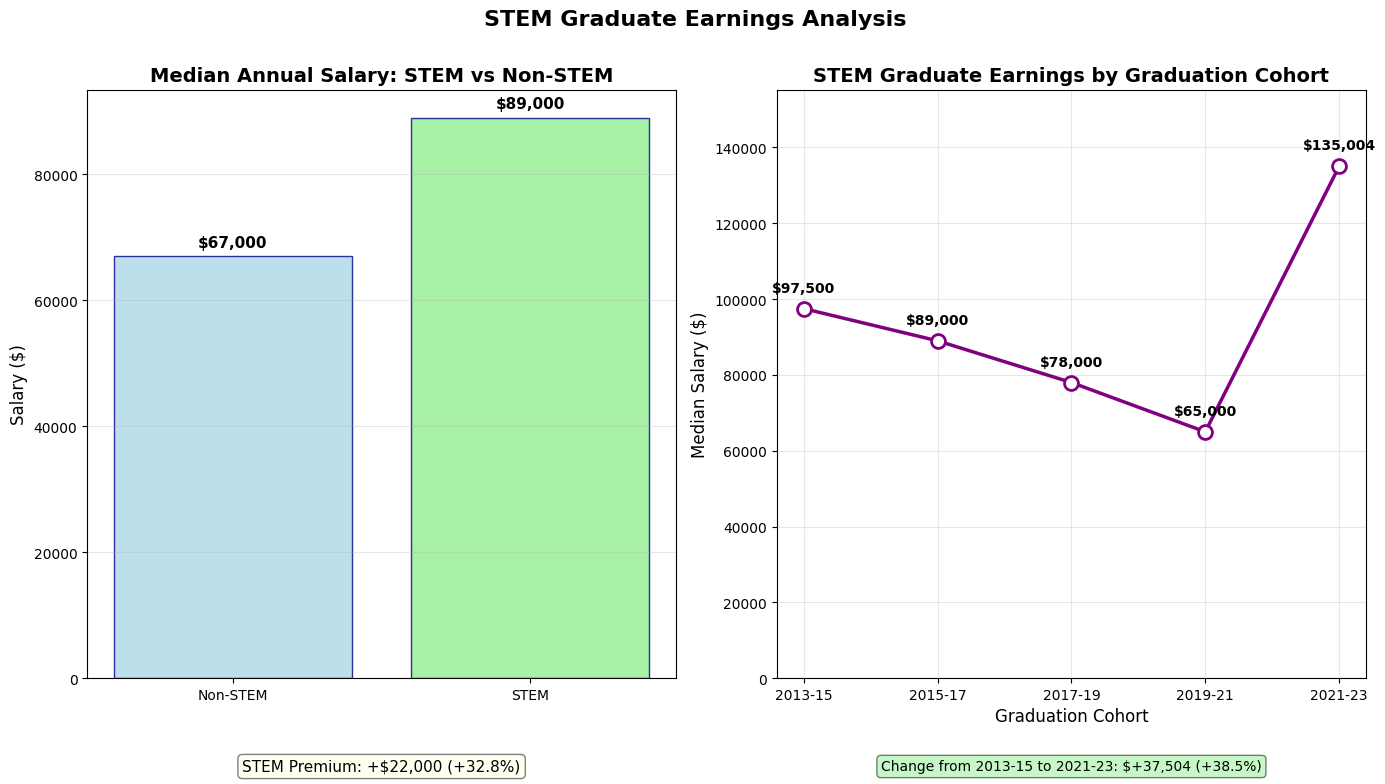

In [15]:
# Create numeric cohort values for plotting
df_recent['cohort_num'] = pd.cut(
    df_recent['BAYR'],
    bins=[2013, 2015, 2017, 2019, 2021, 2023],
    labels=[1, 2, 3, 4, 5]  # Numeric labels
)

# Also create string labels
df_recent['cohort_label'] = pd.cut(
    df_recent['BAYR'],
    bins=[2013, 2015, 2017, 2019, 2021, 2023],
    labels=['2013-15', '2015-17', '2017-19', '2019-21', '2021-23']
)

# Create figure with two charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
fig.suptitle('STEM Graduate Earnings Analysis\n', fontsize=16, fontweight='bold')

# Chart 1: Median Annual Salary - STEM vs Non-STEM
salary_by_stem = df_recent.groupby('is_stem_major')['SALARY'].median()
bars1 = ax1.bar(['Non-STEM', 'STEM'], salary_by_stem.values, 
                color=['lightblue', 'lightgreen'], alpha=0.8, edgecolor='navy', linewidth=1)
ax1.set_title('Median Annual Salary: STEM vs Non-STEM', fontsize=14, fontweight='bold')
ax1.set_ylabel('Salary ($)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add the premium text
stem_salary = salary_by_stem[1]
nonstem_salary = salary_by_stem[0]
premium = ((stem_salary - nonstem_salary) / nonstem_salary) * 100
ax1.text(0.5, -0.15, f'STEM Premium: +${stem_salary - nonstem_salary:,.0f} ({premium:+.1f}%)',
         ha='center', va='center', transform=ax1.transAxes, fontsize=11, 
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

# Chart 2: STEM Graduate Earnings by Cohort
# Get median salary by cohort number
cohort_earnings = df_recent[df_recent['is_stem_major']==1].groupby('cohort_num')['SALARY'].median()
cohort_labels = df_recent.groupby('cohort_num')['cohort_label'].first().sort_index()

# Plot using numeric x-values
ax2.plot(cohort_earnings.index, cohort_earnings.values, 
         marker='o', linewidth=2.5, markersize=10, 
         color='purple', markerfacecolor='white', markeredgewidth=2)

# Set x-axis ticks and labels
ax2.set_xticks(cohort_earnings.index)
ax2.set_xticklabels(cohort_labels)

ax2.set_title('STEM Graduate Earnings by Graduation Cohort', fontsize=14, fontweight='bold')
ax2.set_xlabel('Graduation Cohort', fontsize=12)
ax2.set_ylabel('Median Salary ($)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, cohort_earnings.max() * 1.15)

# Add value labels on points
for i, (cohort_num, salary) in enumerate(cohort_earnings.items()):
    ax2.annotate(f'${salary:,.0f}', 
                xy=(cohort_num, salary), 
                xytext=(0, 10),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

# Calculate and display overall trend
first_salary = cohort_earnings.iloc[0]
last_salary = cohort_earnings.iloc[-1]
change = last_salary - first_salary
change_pct = (change / first_salary) * 100
trend_text = f'Change from {cohort_labels.iloc[0]} to {cohort_labels.iloc[-1]}: ${change:+,.0f} ({change_pct:+.1f}%)'
ax2.text(0.5, -0.15, trend_text, ha='center', va='center', transform=ax2.transAxes,
         fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()

# Print summary statistics
print("\n" + "="*50)
print("STEM EARNINGS SUMMARY")
print("="*50)

print(f"\nOVERALL (Graduates {recent_year}-{max_valid_year}):")
print(f"  STEM median salary: ${stem_salary:,.0f}")
print(f"  Non-STEM median salary: ${nonstem_salary:,.0f}")
print(f"  STEM premium: +${stem_salary - nonstem_salary:,.0f} ({premium:+.1f}%)")

print(f"\nSTEM EARNINGS BY COHORT:")
print("-" * 50)
for cohort_num in cohort_earnings.index:
    label = cohort_labels[cohort_num]
    salary = cohort_earnings[cohort_num]
    print(f"  {label}: ${salary:,.0f}")

# Complete cohort comparison
print("\n" + "="*50)
print("COMPLETE COHORT COMPARISON")
print("="*50)

# Create a dataframe with both STEM and Non-STEM by cohort
comparison_data = []
for cohort_num in cohort_earnings.index:
    cohort_data = df_recent[df_recent['cohort_num'] == cohort_num]
    stem_sal = cohort_data[cohort_data['is_stem_major']==1]['SALARY'].median()
    nonstem_sal = cohort_data[cohort_data['is_stem_major']==0]['SALARY'].median()
    label = cohort_labels[cohort_num]
    comparison_data.append({
        'Cohort': label,
        'STEM': stem_sal,
        'Non-STEM': nonstem_sal,
        'Premium': stem_sal - nonstem_sal,
        'Premium %': ((stem_sal - nonstem_sal) / nonstem_sal * 100) if nonstem_sal > 0 else 0
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(0).to_string(index=False))

## Conclusion: Summary of Issues Encountered and Solved

### Data Integration & Loading Issues

| # | Issue | Problem | Solution |
|---|-------|---------|----------|
| 1 | **Overlapping Data Periods** | 2003-2016 files already contained data through 2021; 2017-2024 files had different sector classifications | Simplified by using only 03-21 files for consistent 19-year analysis |
| 2 | **Multiple Dataset Sources** | Had to work with 3 different files: coverage percentages, multi-state data, and actual enrollment counts | Created separate analysis for each file type for the questions |
| 3 | **Cross-Week Data Integration** | Needed to bring NSCG graduate outcomes data from HW2 into HW4 for STEM earnings analysis | Successfully merged major codes from `N2BAMED.csv` with main survey data using `N2BAMED` as key |
| 4 | **Column Name Standardization** | Year columns had inconsistent formatting (`Fall 2003` vs `Fall_2003`) | Standardized all year columns to `Fall_YYYY` format for consistent access |

### Data Quality & Cleaning Issues

| # | Issue | Problem | Solution |
|---|-------|---------|----------|
| 5 | **Invalid Year Values** | `BAYR` column contained impossible values (9988, 9999) | Filtered to keep only years < 2026 before creating recent graduate cohorts |
| 6 | **Missing Major Field Codes** | Main dataset had major codes but no descriptions; needed external lookup | Used `N2BAMED.csv` as lookup table to map numeric codes to actual field names |
| 7 | **STEM Classification Challenge** | No built-in STEM indicator; needed to define what counts as STEM | Researched NSF definitions and created keyword-based classification |
| 8 | **High STEM Proportion** | Initial classification showed 53.5% STEM graduates - suspiciously high | Refined STEM keywords to be more precise; double-checked against known STEM field codes - still high, maybe true |

### Visualization & Analysis Issues

| # | Issue | Problem | Solution |
|---|-------|---------|----------|
| 9 | **X-Axis Label Conversion Error** | Matplotlib couldn't convert string cohort labels ('2013-15') to axis units | Used numeric cohort indices (1-5) for plotting, then mapped to string labels |
| 10 | **STEM Premium Calculation** | Needed to quantify the financial advantage of STEM degrees | Calculated both absolute ($) and relative (%) premium across cohorts |